In [3]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import *
from sklearn.ensemble import *
from sklearn.feature_selection import *
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import *
from sklearn.metrics import *
from sklearn.preprocessing import *
from sklearn.pipeline import *
from sklearn.svm import *
from sklearn.tree import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import constantes as const

In [21]:
from utils.data import DataManager

data_manager = DataManager()
data_manager.preparar_conjuntos()

X_train, y_train, weights_train = data_manager.get_train_data()
X, y = data_manager.get_X_y()
test = data_manager.get_test()
weights = data_manager.get_weights()
X_test, y_test, weights_test = data_manager.get_test_data()


In [ ]:
from utils.preprocess import DataPreprocessor
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier

data_preprocessor = DataPreprocessor()

model = AdaBoostClassifier(RandomForestClassifier(n_jobs=-1))


full_pipeline = Pipeline(steps=[('preprocessor', data_preprocessor),
                                ('classifier', model)])

y_probas_forest = cross_val_predict(full_pipeline, X_train, y_train, cv=3, method="predict_proba")

y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_scores_forest)

plt.figure(figsize=(8, 6))
plt.plot(fpr_forest, tpr_forest, label='ROC curve (area = %0.2f)' % auc(fpr_forest, tpr_forest))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc="lower right")
plt.show()

In [17]:
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from utils.metrics import MetricsManager

full_pipeline.fit(X_train, y_train, classifier__sample_weight=weights_train)
y_probas = full_pipeline.predict_proba(X_test)
y_scores = y_probas[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)


best_threshold = MetricsManager.get_best_threshold(precision, recall, thresholds)

y_pred_optimal = (y_scores >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_optimal))

c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.88      0.85      0.86     33030
           1       0.72      0.77      0.75     16970

    accuracy                           0.82     50000
   macro avg       0.80      0.81      0.81     50000
weighted avg       0.83      0.82      0.82     50000



In [20]:
y_test_proba = full_pipeline.predict_proba(test)
y_test_scores = y_test_proba[:, 1]
y_test_pred = (y_test_scores >= best_threshold).astype(int)

submission_df = pd.DataFrame({
    "EventId": test["EventId"],
    "Class": y_test_pred,
    "Probability": y_test_scores
})

submission_df = submission_df.sort_values(by='Probability', ascending=False)

submission_df['RankOrder'] = range(1, len(submission_df) + 1)
submission_df['Class'] = submission_df['Class'].map({1: 's', 0: 'b'})

submission_df = submission_df[['EventId', 'Class', 'RankOrder']]

submission_df.to_csv("submission.csv", index=False)

In [21]:
!kaggle competitions submit -c higgs-boson -f submission.csv -m "ADABoost + Random Forest"

Successfully submitted to Higgs Boson Machine Learning Challenge



  0%|          | 0.00/8.81M [00:00<?, ?B/s]
  2%|▏         | 176k/8.81M [00:00<00:05, 1.78MB/s]
 11%|█         | 968k/8.81M [00:00<00:01, 5.13MB/s]
 16%|█▌        | 1.42M/8.81M [00:00<00:01, 4.72MB/s]
 26%|██▌       | 2.25M/8.81M [00:00<00:01, 6.18MB/s]
 32%|███▏      | 2.85M/8.81M [00:00<00:01, 3.22MB/s]
 37%|███▋      | 3.30M/8.81M [00:01<00:02, 2.78MB/s]
 41%|████▏     | 3.66M/8.81M [00:01<00:02, 2.64MB/s]
 45%|████▌     | 3.98M/8.81M [00:01<00:01, 2.79MB/s]
 49%|████▉     | 4.36M/8.81M [00:01<00:01, 3.03MB/s]
 54%|█████▎    | 4.73M/8.81M [00:01<00:01, 3.24MB/s]
 59%|█████▊    | 5.16M/8.81M [00:01<00:01, 3.42MB/s]
 63%|██████▎   | 5.54M/8.81M [00:01<00:00, 3.55MB/s]
 67%|██████▋   | 5.92M/8.81M [00:01<00:00, 3.64MB/s]
 72%|███████▏  | 6.34M/8.81M [00:01<00:00, 3.72MB/s]
 76%|███████▋  | 6.73M/8.81M [00:02<00:00, 3.76MB/s]
 81%|████████  | 7.15M/8.81M [00:02<00:00, 3.80MB/s]
 85%|████████▌ | 7.52M/8.81M [00:02<00:00, 3.83MB/s]
 90%|█████████ | 7.95M/8.81M [00:02<00:00, 3.83MB/s]
 94

c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


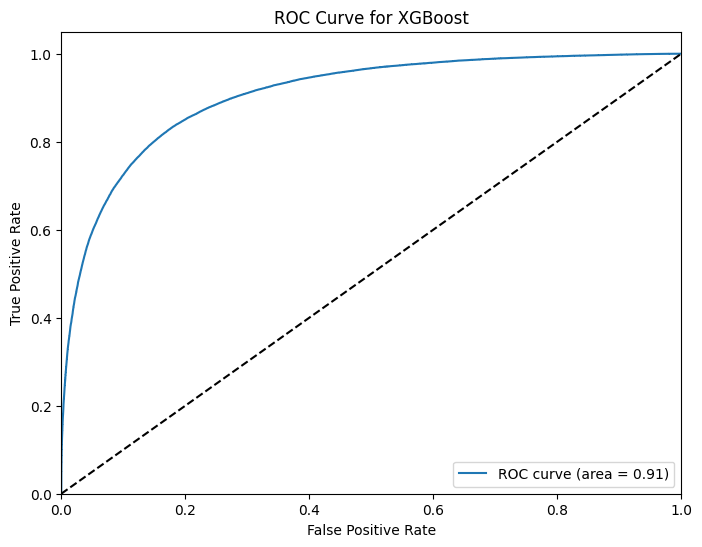

In [12]:
from utils.preprocess import DataPreprocessor
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier

data_preprocessor = DataPreprocessor()

X_train, X_val, y_train, y_val, weights_train, weights_val = train_test_split(
    X_train, y_train, weights_train, test_size=0.1, random_state=42
)

model = AdaBoostClassifier(ExtraTreesClassifier(n_estimators=400, min_samples_split= 6, min_samples_leaf= 7, max_features='sqrt', max_depth=14,n_jobs=-1), n_estimators=20)

"""model = AdaBoostClassifier(ExtraTreesClassifier(
    n_estimators=400,
    max_features=30,
    max_depth=12,
    min_samples_leaf=100,
    min_samples_split=100,
    verbose=1,
    n_jobs=-1),
    n_estimators=20,
    learning_rate=0.75
)"""


full_pipeline = Pipeline(steps=[('preprocessor', data_preprocessor),
                                ('classifier', model)])

y_probas_forest = cross_val_predict(full_pipeline, X_train, y_train, cv=3, method="predict_proba")

y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_scores_forest)

plt.figure(figsize=(8, 6))
plt.plot(fpr_forest, tpr_forest, label='ROC curve (area = %0.2f)' % auc(fpr_forest, tpr_forest))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc="lower right")
plt.show()

c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


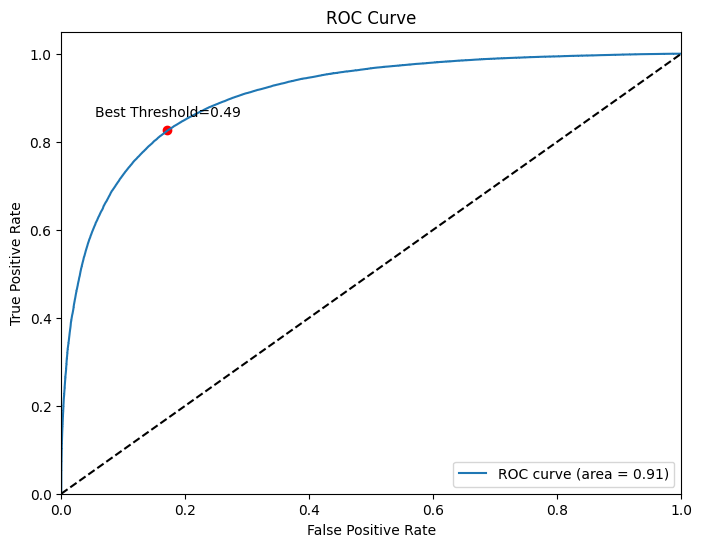

Best Threshold:  0.4883657996287055


In [17]:
y_probas_forest = cross_val_predict(full_pipeline, X_train, y_train, cv=3, method="predict_proba")
y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_scores_forest)

J = tpr_forest - fpr_forest
idx = np.argmax(J)
best_thresh = thresholds_forest[idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr_forest, tpr_forest, label='ROC curve (area = %0.2f)' % auc(fpr_forest, tpr_forest))
plt.plot([0, 1], [0, 1], 'k--')
plt.scatter(fpr_forest[idx], tpr_forest[idx], c='red')  # Marcar el mejor punto
plt.annotate(f'Best Threshold={best_thresh:.2f}', (fpr_forest[idx], tpr_forest[idx]), textcoords="offset points", xytext=(0,10), ha='center')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

print("Best Threshold: ", best_thresh)

In [18]:
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from utils.metrics import MetricsManager

full_pipeline.fit(X_train, y_train, classifier__sample_weight=weights_train)
y_probas = full_pipeline.predict_proba(X_val)
y_scores = y_probas[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, y_scores)

y_pred_optimal = (y_scores >= best_thresh).astype(int)

print(classification_report(y_val, y_pred_optimal))

c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.70      1.00      0.82     13186
           1       0.96      0.18      0.30      6814

    accuracy                           0.72     20000
   macro avg       0.83      0.59      0.56     20000
weighted avg       0.79      0.72      0.65     20000



In [19]:
import utils.HiggsBosonCompetition_AMSMetric_rev1 as hb_metrics
import importlib

hb_metrics.ams_scorer(y_val, y_pred_optimal, weights_val)

signal = 4.22688705530925
background = 30.5269465999684


0.6529029845611655

In [16]:
hb_metrics.ams_scorer(y_val, y_pred, weights_val)

signal = 2.07606333734664
background = 6.5141742328077


0.5006926735776726

c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


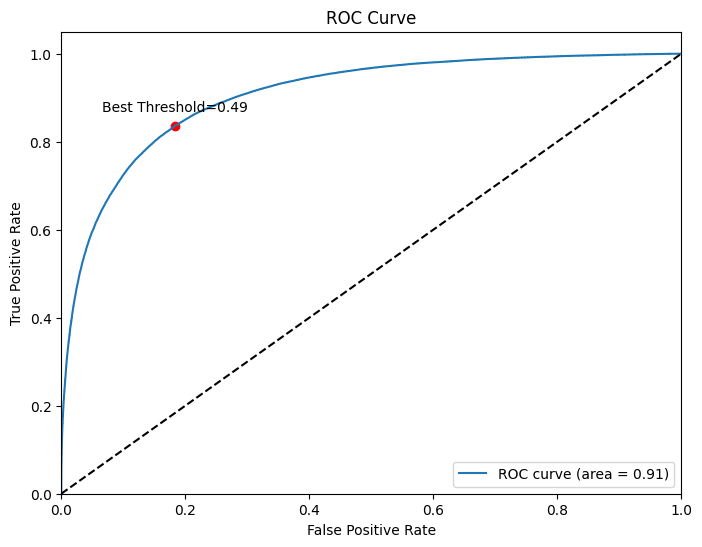

Best Threshold:  0.48715958446423435


In [8]:
y_probas_forest = cross_val_predict(full_pipeline, X_train, y_train, cv=3, method="predict_proba")
y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_scores_forest)

J = tpr_forest - fpr_forest
idx = np.argmax(J)
best_thresh = thresholds_forest[idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr_forest, tpr_forest, label='ROC curve (area = %0.2f)' % auc(fpr_forest, tpr_forest))
plt.plot([0, 1], [0, 1], 'k--')
plt.scatter(fpr_forest[idx], tpr_forest[idx], c='red')  # Marcar el mejor punto
plt.annotate(f'Best Threshold={best_thresh:.2f}', (fpr_forest[idx], tpr_forest[idx]), textcoords="offset points", xytext=(0,10), ha='center')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

print("Best Threshold: ", best_thresh)

In [9]:
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from utils.metrics import MetricsManager

full_pipeline.fit(X_train, y_train, classifier__sample_weight=weights_train)
y_probas = full_pipeline.predict_proba(X_test)
y_scores = y_probas[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

y_pred_optimal = (y_scores >= best_thresh).astype(int)

print(classification_report(y_test, y_pred_optimal))

c:\Users\Valen\Desktop\Laboratorio1_TAA\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.70      1.00      0.83     33030
           1       0.96      0.19      0.31     16970

    accuracy                           0.72     50000
   macro avg       0.83      0.59      0.57     50000
weighted avg       0.79      0.72      0.65     50000



In [11]:
!kaggle competitions submit -c higgs-boson -f submission.csv -m "ADABoost + Extra trees"

Successfully submitted to Higgs Boson Machine Learning Challenge



  0%|          | 0.00/8.81M [00:00<?, ?B/s]
  2%|▏         | 200k/8.81M [00:00<00:04, 2.02MB/s]
 11%|█         | 968k/8.81M [00:00<00:01, 5.41MB/s]
 17%|█▋        | 1.47M/8.81M [00:00<00:01, 4.91MB/s]
 26%|██▌       | 2.28M/8.81M [00:00<00:01, 6.23MB/s]
 33%|███▎      | 2.89M/8.81M [00:00<00:01, 3.23MB/s]
 38%|███▊      | 3.34M/8.81M [00:01<00:02, 2.42MB/s]
 42%|████▏     | 3.72M/8.81M [00:01<00:02, 2.66MB/s]
 46%|████▋     | 4.09M/8.81M [00:01<00:01, 2.90MB/s]
 51%|█████     | 4.47M/8.81M [00:01<00:01, 3.12MB/s]
 55%|█████▍    | 4.84M/8.81M [00:01<00:01, 3.30MB/s]
 59%|█████▉    | 5.22M/8.81M [00:01<00:01, 3.45MB/s]
 63%|██████▎   | 5.59M/8.81M [00:01<00:00, 3.57MB/s]
 68%|██████▊   | 5.97M/8.81M [00:01<00:00, 3.65MB/s]
 72%|███████▏  | 6.35M/8.81M [00:01<00:00, 3.72MB/s]
 76%|███████▋  | 6.73M/8.81M [00:02<00:00, 3.77MB/s]
 81%|████████  | 7.10M/8.81M [00:02<00:00, 3.81MB/s]
 85%|████████▍ | 7.48M/8.81M [00:02<00:00, 3.84MB/s]
 89%|████████▉ | 7.85M/8.81M [00:02<00:00, 3.86MB/s]
 93

In [ ]:
from utils.preprocess import DataPreprocessor
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier

data_preprocessor = DataPreprocessor()

model = AdaBoostClassifier(ExtraTreesClassifier())


full_pipeline = Pipeline(steps=[('preprocessor', data_preprocessor),
                                ('classifier', model)])

y_probas_forest = cross_val_predict(full_pipeline, X_train, y_train, cv=3, method="predict_proba")

y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_scores_forest)

plt.figure(figsize=(8, 6))
plt.plot(fpr_forest, tpr_forest, label='ROC curve (area = %0.2f)' % auc(fpr_forest, tpr_forest))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc="lower right")
plt.show()


In [ ]:
from utils.preprocess import DataPreprocessor
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier

data_preprocessor = DataPreprocessor()

model = AdaBoostClassifier(ExtraTreesClassifier(
    n_estimators=400,
    max_features=30,
    max_depth=12,
    min_samples_leaf=100,
    min_samples_split=100,
    verbose=1,
    n_jobs=-1),
    n_estimators=20,
    learning_rate=0.75
)


full_pipeline = Pipeline(steps=[('preprocessor', data_preprocessor),
                                ('classifier', model)])

y_probas_forest = cross_val_predict(full_pipeline, X_train, y_train, cv=3, method="predict_proba")

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from utils.metrics import MetricsManager

full_pipeline.fit(X_train, y_train, classifier__sample_weight=weights_train)
y_probas = full_pipeline.predict_proba(X_test)
y_scores = y_probas[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)


best_threshold = MetricsManager.get_best_threshold(precision, recall, thresholds)

y_pred_optimal = (y_scores >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_optimal))

In [ ]:
y_test_proba = full_pipeline.predict_proba(test)
y_test_scores = y_test_proba[:, 1]
y_test_pred = (y_test_scores >= best_threshold).astype(int)

submission_df = pd.DataFrame({
    "EventId": test["EventId"],
    "Class": y_test_pred,
    "Probability": y_test_scores
})

submission_df = submission_df.sort_values(by='Probability', ascending=False)

submission_df['RankOrder'] = range(1, len(submission_df) + 1)
submission_df['Class'] = submission_df['Class'].map({1: 's', 0: 'b'})

submission_df = submission_df[['EventId', 'Class', 'RankOrder']]

submission_df.to_csv("submission.csv", index=False)


In [14]:
!kaggle competitions submit -c higgs-boson -f submission.csv -m "ADABoost + ExtraTreesClassifier"

Successfully submitted to Higgs Boson Machine Learning Challenge



  0%|          | 0.00/8.81M [00:00<?, ?B/s]
  1%|          | 96.0k/8.81M [00:00<00:09, 960kB/s]
  7%|▋         | 640k/8.81M [00:00<00:02, 3.64MB/s]
 14%|█▍        | 1.25M/8.81M [00:00<00:01, 4.93MB/s]
 20%|█▉        | 1.73M/8.81M [00:00<00:01, 4.49MB/s]
 25%|██▍       | 2.16M/8.81M [00:00<00:02, 3.18MB/s]
 29%|██▊       | 2.52M/8.81M [00:01<00:03, 2.03MB/s]
 32%|███▏      | 2.85M/8.81M [00:01<00:02, 2.30MB/s]
 36%|███▌      | 3.14M/8.81M [00:01<00:02, 2.23MB/s]
 40%|███▉      | 3.52M/8.81M [00:01<00:02, 2.59MB/s]
 44%|████▍     | 3.90M/8.81M [00:01<00:01, 2.90MB/s]
 49%|████▊     | 4.27M/8.81M [00:01<00:01, 3.15MB/s]
 53%|█████▎    | 4.65M/8.81M [00:01<00:01, 3.36MB/s]
 57%|█████▋    | 5.02M/8.81M [00:01<00:01, 3.50MB/s]
 61%|██████▏   | 5.41M/8.81M [00:01<00:00, 3.64MB/s]
 66%|██████▌   | 5.78M/8.81M [00:01<00:00, 3.71MB/s]
 70%|██████▉   | 6.16M/8.81M [00:02<00:00, 3.77MB/s]
 74%|███████▍  | 6.54M/8.81M [00:02<00:00, 3.83MB/s]
 79%|███████▊  | 6.92M/8.81M [00:02<00:00, 3.86MB/s]
 83

In [50]:
X = data_preprocessor.fit_transform(X)
X_test = data_preprocessor.transform(test)


In [ ]:
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import make_scorer
import numpy as np
import importlib
import utils.comet_experiments as comet_exp
import utils.HiggsBosonCompetition_AMSMetric_rev1 as hb_metrics

importlib.reload(hb_metrics)
importlib.reload(comet_exp)

# Definir la función de puntuación personalizada
ams_custom_score = make_scorer(hb_metrics.ams_scorer, greater_is_better=True, needs_proba=False)

# Preparar los datos
X_train, X_val, y_train, y_val, weights_train, weights_val = train_test_split(
    X, y, weights, test_size=0.1, random_state=42
)

# Definir el modelo de AdaBoost con ExtraTrees como estimador base
model = AdaBoostClassifier(
    estimator=ExtraTreesClassifier(
        n_jobs=-1
    ),
)

# Definir los parámetros para RandomizedSearchCV
param_dist = {
    'estimator__n_estimators': np.arange(100, 500, 100),
    'estimator__max_features': np.arange(10, 50, 10),
    'estimator__max_depth': np.arange(5, 20, 5),
    'estimator__min_samples_split': np.arange(50, 100, 50),
    'estimator__min_samples_leaf': np.arange(50, 100, 50),
    'n_estimators': np.arange(10, 100, 10),
    'learning_rate': np.linspace(0.25, 1.0, 4)
}

# Configurar RandomizedSearchCV
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=15,
    scoring=ams_custom_score,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1  # Usar un solo proceso para evitar problemas de paralelización
)

# Ajustar el modelo
random_search.fit(X_train, y_train, sample_weight=weights_train)

# Mostrar los mejores parámetros y el mejor puntaje
print("Mejores parámetros:", random_search.best_params_)
print("Mejor puntaje:", random_search.best_score_)
